# <span style="color:green; font-weight:bold">PROBLEM 2 - Sectoral Segmentation</span>

#### In the competitive landscape of any industry sector, monitoring company performance through quarterly balance sheets is crucial for identifying potential risks and opportunities. Your task is to develop a system that detects company segments based on performance of companies within a specific industry sector, using their quarterly balance sheet data.

#### Find company performance based on their balance sheets of the last financial year or quarter.


============================================================================
### <span style="color: blue; font-weight:bold">MODULE 1: EXPLORATORY DATA ANALYSIS (EDA)</span>
============================================================================

PHARMACEUTICAL SECTOR - FINANCIAL RATIO ANALYSIS

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Dataset Shape: 50 companies, 14 features

Cleaned Column Names:
   1. S.No.
   2. Name
   3. CMP Rs.
   4. NP Qtr Rs.Cr.
   5. ROA 12M %
   6. ROE %
   7. Debt / Eq
   8. Current ratio
   9. Sales growth %
   10. PAT Qtr Rs.Cr.
   11. ROCE %
   12. Asset Turnover
   13. NPM Ann %
   14. Mar Cap Rs.Cr.

2. FIRST 5 COMPANIES
--------------------------------------------------------------------------------
   S.No.             Name  CMP Rs.  NP Qtr Rs.Cr.  ROA 12M %  ROE %  \
0      1  Sun Pharma.Inds   1658.5        2292.87      12.97  16.86   
1      2       Divi's Lab   6132.0         545.00      13.53  15.35   
2      3            Cipla   1513.1        1291.61      14.72  17.77   
3      4   Torrent Pharma   3550.5         548.00      13.26  26.52   
4      5  Dr Reddy's Labs   1246.1        1409.90      12.95  17.96   

   Debt / Eq  Cu

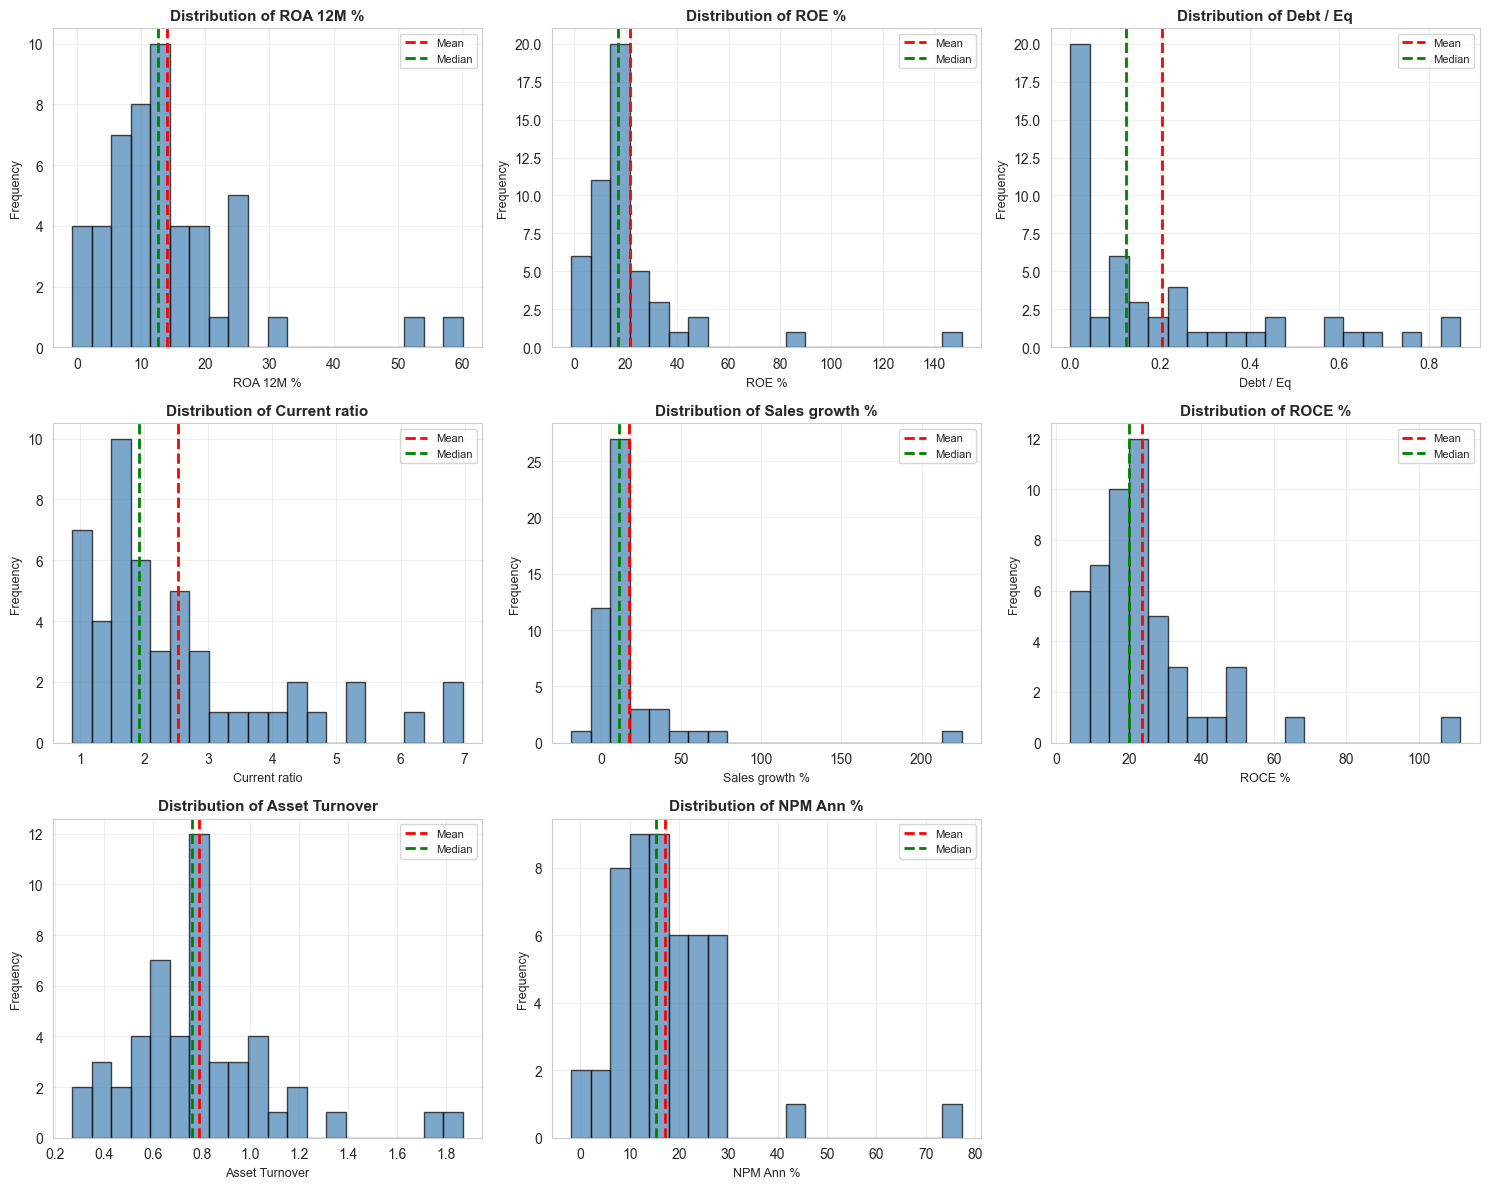

✓ Distribution plots saved!

7. CREATING BOX PLOTS FOR OUTLIER DETECTION...


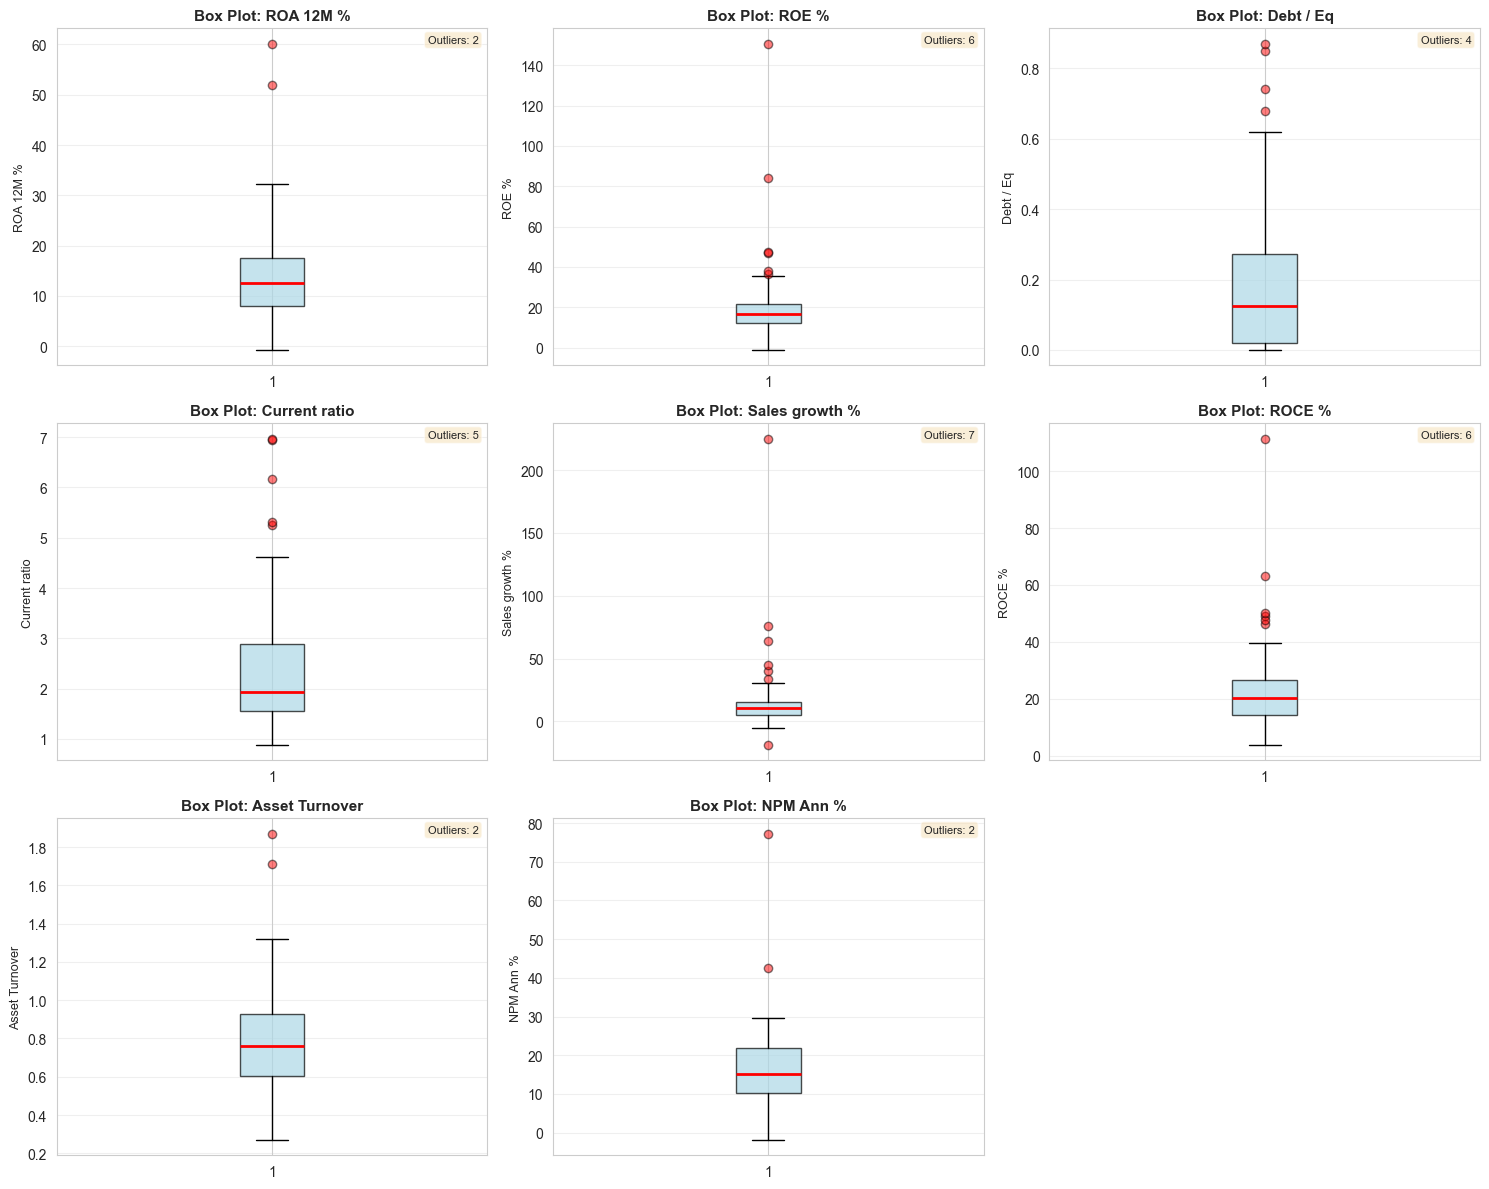

✓ Box plots saved!

8. CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Correlation Matrix:
                ROA 12M %  ROE %  Debt / Eq  Current ratio  Sales growth %  \
ROA 12M %           1.000  0.932     -0.232          0.204          -0.105   
ROE %               0.932  1.000      0.014         -0.011          -0.102   
Debt / Eq          -0.232  0.014      1.000         -0.561          -0.048   
Current ratio       0.204 -0.011     -0.561          1.000          -0.110   
Sales growth %     -0.105 -0.102     -0.048         -0.110           1.000   
ROCE %              0.727  0.531     -0.427          0.174          -0.124   
Asset Turnover      0.587  0.455     -0.316         -0.010          -0.187   
NPM Ann %           0.844  0.833     -0.166          0.349          -0.061   

                ROCE %  Asset Turnover  NPM Ann %  
ROA 12M %        0.727           0.587      0.844  
ROE %            0.531           0.455      0.8

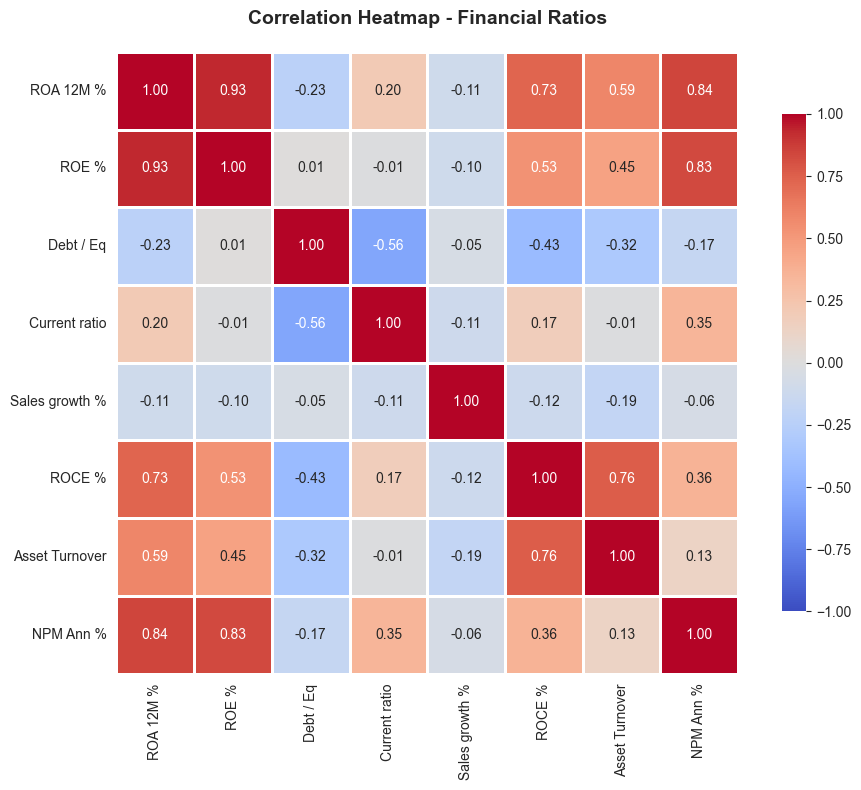

✓ Correlation heatmap saved!

9. BIVARIATE ANALYSIS - KEY RELATIONSHIPS
--------------------------------------------------------------------------------


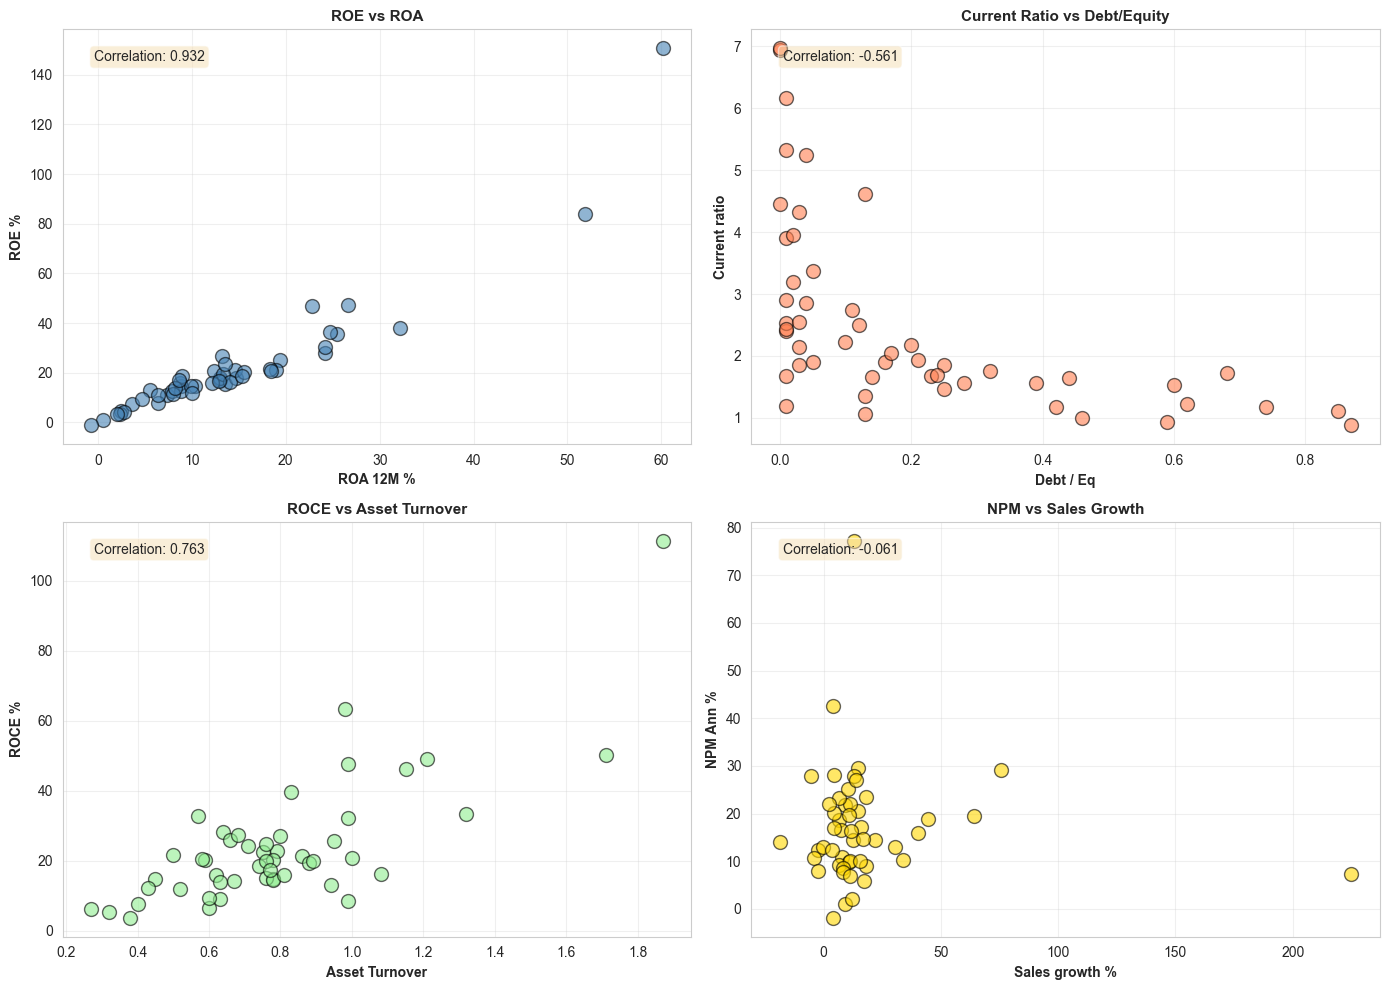

✓ Bivariate analysis plots saved!

10. OUTLIER DETECTION USING IQR METHOD
--------------------------------------------------------------------------------
       Feature  Outliers_Count  Lower_Bound  Upper_Bound                                   Outlier_Companies
     ROA 12M %               2        -6.64        32.17                     Sanofi Consumer, Strides Pharma
         ROE %               6        -2.26        35.86     Glaxosmi. Pharma, Sanofi India, Sanofi Consumer
     Debt / Eq               4        -0.36         0.65            Biocon, ERIS Lifescience, Strides Pharma
 Current ratio               5        -0.44         4.90                Divi's Lab, Pfizer, Caplin Point Lab
Sales growth %               7       -10.92        31.76 Cohance Life, Astrazeneca Phar, OneSource Specimens
        ROCE %               6        -4.36        45.42        Abbott India, Glaxosmi. Pharma, Sanofi India
Asset Turnover               2         0.12         1.41                        Sa

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load and clean the dataset
df = pd.read_csv('Pharma-Sector-Finance-Data.csv', encoding='utf-8')

# CRITICAL FIX: Remove non-breaking spaces from column names
df.columns = df.columns.str.replace('\xa0', ' ').str.strip()

print("="*80)
print("PHARMACEUTICAL SECTOR - FINANCIAL RATIO ANALYSIS")
print("="*80)

# 1. Basic Dataset Information
print("\n1. DATASET OVERVIEW")
print("-"*80)
print(f"Dataset Shape: {df.shape[0]} companies, {df.shape[1]} features")
print(f"\nCleaned Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# 2. Display first few rows
print("\n2. FIRST 5 COMPANIES")
print("-"*80)
print(df.head())

# 3. Data types and missing values
print("\n3. DATA TYPES AND MISSING VALUES")
print("-"*80)
print(df.info())
print(f"\nMissing Values:\n{df.isnull().sum()}")

# 4. Statistical Summary
print("\n4. STATISTICAL SUMMARY")
print("-"*80)
print(df.describe().T)

# 5. Select key financial ratios for visualization
key_ratios = ['ROA 12M %', 'ROE %', 'Debt / Eq', 'Current ratio', 
              'Sales growth %', 'ROCE %', 'Asset Turnover', 'NPM Ann %']

print(f"\n5. KEY FINANCIAL RATIOS FOR ANALYSIS ({len(key_ratios)} ratios):")
print("-"*80)
for i, ratio in enumerate(key_ratios, 1):
    print(f"   {i}. {ratio}")

# 6. Distribution Analysis
print("\n6. CREATING DISTRIBUTION PLOTS...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(key_ratios):
    if idx < len(axes):
        # Histogram with KDE
        data = df[col].dropna()
        axes[idx].hist(data, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label='Median')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplot
if len(key_ratios) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution plots saved!")

# 7. Box plots for outlier detection
print("\n7. CREATING BOX PLOTS FOR OUTLIER DETECTION...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(key_ratios):
    if idx < len(axes):
        data = df[col].dropna()
        bp = axes[idx].boxplot(data, vert=True, patch_artist=True,
                               boxprops=dict(facecolor='lightblue', alpha=0.7),
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
        axes[idx].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=9)
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add statistics text
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
        axes[idx].text(0.98, 0.98, f'Outliers: {len(outliers)}', 
                      transform=axes[idx].transAxes, 
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=8)

# Remove empty subplot
if len(key_ratios) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Box plots saved!")

# 8. Correlation Matrix
print("\n8. CORRELATION ANALYSIS")
print("-"*80)

correlation_matrix = df[key_ratios].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Financial Ratios', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved!")

# 9. Scatter plots for key relationships
print("\n9. BIVARIATE ANALYSIS - KEY RELATIONSHIPS")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROE vs ROA
axes[0,0].scatter(df['ROA 12M %'], df['ROE %'], alpha=0.6, s=100, c='steelblue', edgecolors='black')
axes[0,0].set_xlabel('ROA 12M %', fontsize=10, fontweight='bold')
axes[0,0].set_ylabel('ROE %', fontsize=10, fontweight='bold')
axes[0,0].set_title('ROE vs ROA', fontsize=11, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)
# Add correlation coefficient
corr = df[['ROA 12M %', 'ROE %']].corr().iloc[0,1]
axes[0,0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0,0].transAxes,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Current Ratio vs Debt/Equity
axes[0,1].scatter(df['Debt / Eq'], df['Current ratio'], alpha=0.6, s=100, c='coral', edgecolors='black')
axes[0,1].set_xlabel('Debt / Eq', fontsize=10, fontweight='bold')
axes[0,1].set_ylabel('Current ratio', fontsize=10, fontweight='bold')
axes[0,1].set_title('Current Ratio vs Debt/Equity', fontsize=11, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)
corr = df[['Debt / Eq', 'Current ratio']].corr().iloc[0,1]
axes[0,1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0,1].transAxes,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ROCE vs Asset Turnover
axes[1,0].scatter(df['Asset Turnover'], df['ROCE %'], alpha=0.6, s=100, c='lightgreen', edgecolors='black')
axes[1,0].set_xlabel('Asset Turnover', fontsize=10, fontweight='bold')
axes[1,0].set_ylabel('ROCE %', fontsize=10, fontweight='bold')
axes[1,0].set_title('ROCE vs Asset Turnover', fontsize=11, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
corr = df[['Asset Turnover', 'ROCE %']].corr().iloc[0,1]
axes[1,0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1,0].transAxes,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Sales Growth vs NPM
axes[1,1].scatter(df['Sales growth %'], df['NPM Ann %'], alpha=0.6, s=100, c='gold', edgecolors='black')
axes[1,1].set_xlabel('Sales growth %', fontsize=10, fontweight='bold')
axes[1,1].set_ylabel('NPM Ann %', fontsize=10, fontweight='bold')
axes[1,1].set_title('NPM vs Sales Growth', fontsize=11, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
corr = df[['Sales growth %', 'NPM Ann %']].corr().iloc[0,1]
axes[1,1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1,1].transAxes,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bivariate analysis plots saved!")

# 10. Identify outliers using IQR method
print("\n10. OUTLIER DETECTION USING IQR METHOD")
print("-"*80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_summary = []
for col in key_ratios:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outliers_Count': len(outliers),
        'Lower_Bound': round(lower, 2),
        'Upper_Bound': round(upper, 2),
        'Outlier_Companies': ', '.join(df.loc[outliers.index, 'Name'].tolist()[:3]) if len(outliers) > 0 else 'None'
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

print("\n" + "="*80)
print("EDA COMPLETE - Key Insights:")
print("="*80)
print("✓ Dataset loaded successfully with 50 pharmaceutical companies")
print("✓ All column names cleaned (removed non-breaking spaces)")
print("✓ Distribution plots show varying performance across ratios")
print("✓ Outliers identified in multiple features")
print(f"✓ Strong positive correlations: ROA-ROE ({df[['ROA 12M %', 'ROE %']].corr().iloc[0,1]:.3f}), ROA-ROCE ({df[['ROA 12M %', 'ROCE %']].corr().iloc[0,1]:.3f})")
print("✓ Data ready for standardization and clustering analysis")
print("="*80)


============================================================================
### <span style="color: blue; font-weight:bold">MODULE 2: DATA STANDARDIZATION</span>
============================================================================


MODULE 2: DATA STANDARDIZATION

1. SELECTED FEATURES FOR CLUSTERING (8 features):
--------------------------------------------------------------------------------
   1. ROA 12M %
   2. ROE %
   3. Debt / Eq
   4. Current ratio
   5. Sales growth %
   6. ROCE %
   7. Asset Turnover
   8. NPM Ann %

2. FEATURE MATRIX SHAPE: (50, 8)
--------------------------------------------------------------------------------
   Companies: 50
   Features: 8

3. CHECKING FOR MISSING VALUES
--------------------------------------------------------------------------------
ROA 12M %         0
ROE %             0
Debt / Eq         0
Current ratio     0
Sales growth %    0
ROCE %            0
Asset Turnover    0
NPM Ann %         0
dtype: int64
✓ No missing values found!

4. STATISTICS BEFORE STANDARDIZATION
--------------------------------------------------------------------------------
                   mean        std    min     max
ROA 12M %       14.0072  11.379242  -0.73   60.15
ROE %           21.718

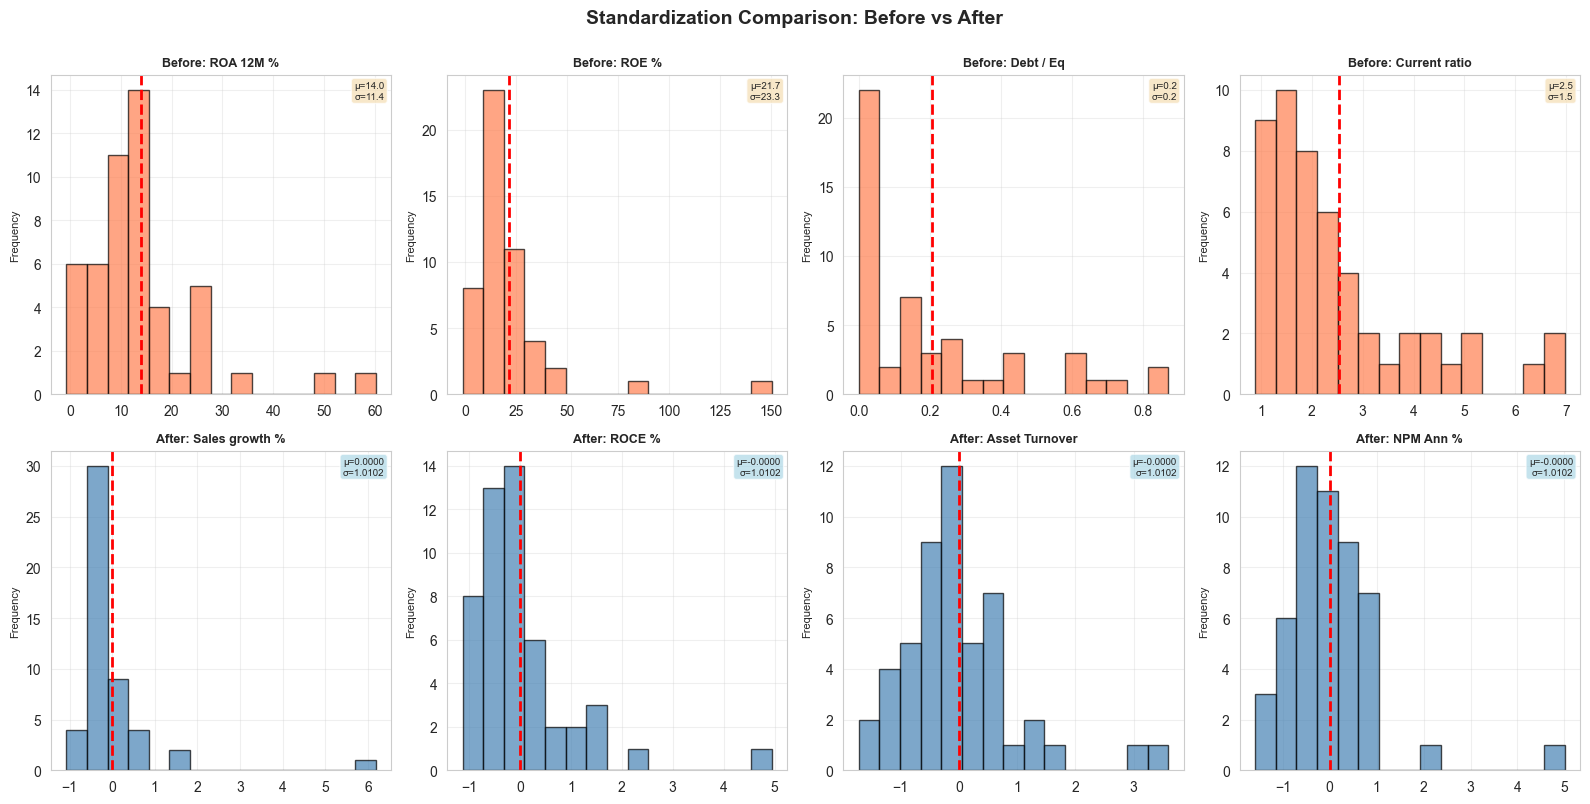

✓ Comparison plots saved!

9. ALTERNATIVE SCALING METHOD: MIN-MAX SCALING
--------------------------------------------------------------------------------
   Formula: x_scaled = (x - x_min) / (x_max - x_min)
   Range: [0, 1]
   Note: We'll use Standard Scaling for clustering (better for outliers)

   Min-Max Scaled Statistics:
                  mean  min  max
ROA 12M %       0.2421  0.0  1.0
ROE %           0.1510  0.0  1.0
Debt / Eq       0.2359  0.0  1.0
Current ratio   0.2710  0.0  1.0
Sales growth %  0.1483  0.0  1.0
ROCE %          0.1853  0.0  1.0
Asset Turnover  0.3234  0.0  1.0
NPM Ann %       0.2414  0.0  1.0

10. CREATING FINAL SCALED DATASET
--------------------------------------------------------------------------------
   First 5 companies (scaled features):
           Company  ROA 12M %     ROE %  Debt / Eq  Current ratio  \
0  Sun Pharma.Inds  -0.092074 -0.211020  -0.729311      -0.256188   
1       Divi's Lab  -0.042362 -0.276605  -0.854192       2.892054   
2          

In [5]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("\n" + "="*80)
print("MODULE 2: DATA STANDARDIZATION")
print("="*80)

# 1. Prepare data for clustering
# Select only financial ratios (exclude identifiers and absolute values)
clustering_features = ['ROA 12M %', 'ROE %', 'Debt / Eq', 'Current ratio', 
                       'Sales growth %', 'ROCE %', 'Asset Turnover', 'NPM Ann %']

print(f"\n1. SELECTED FEATURES FOR CLUSTERING ({len(clustering_features)} features):")
print("-"*80)
for i, feat in enumerate(clustering_features, 1):
    print(f"   {i}. {feat}")

# Extract features for clustering
X = df[clustering_features].copy()

# Store company names for later reference
company_names = df['Name'].values

print(f"\n2. FEATURE MATRIX SHAPE: {X.shape}")
print("-"*80)
print(f"   Companies: {X.shape[0]}")
print(f"   Features: {X.shape[1]}")

# 3. Check for missing values
print(f"\n3. CHECKING FOR MISSING VALUES")
print("-"*80)
missing_values = X.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print(f"\n⚠️  Found {missing_values.sum()} missing values. Imputing with median...")
    X = X.fillna(X.median())
    print("✓ Missing values imputed!")
else:
    print("✓ No missing values found!")

# 4. Before standardization - statistics
print(f"\n4. STATISTICS BEFORE STANDARDIZATION")
print("-"*80)
stats_before = X.describe().T[['mean', 'std', 'min', 'max']]
print(stats_before)

# 5. Standard Scaler (Z-score normalization)
print(f"\n5. APPLYING STANDARD SCALER (Z-SCORE NORMALIZATION)")
print("-"*80)
print("   Formula: z = (x - μ) / σ")
print("   Where μ = mean, σ = standard deviation")
print("   This transforms data to have mean = 0 and std = 1")

scaler_standard = StandardScaler()
X_scaled = scaler_standard.fit_transform(X)

# Convert to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=df.index)

print(f"\n6. STATISTICS AFTER STANDARDIZATION")
print("-"*80)
stats_after = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
print(stats_after.round(4))

# 7. Comparison Table
print(f"\n7. BEFORE/AFTER COMPARISON")
print("-"*80)
comparison_df = pd.DataFrame({
    'Feature': clustering_features,
    'Original_Mean': stats_before['mean'].round(2).values,
    'Original_Std': stats_before['std'].round(2).values,
    'Scaled_Mean': stats_after['mean'].round(4).values,
    'Scaled_Std': stats_after['std'].round(4).values
})
print(comparison_df.to_string(index=False))

# 8. Visualization: Before vs After Standardization
print(f"\n8. CREATING BEFORE/AFTER STANDARDIZATION COMPARISON...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, col in enumerate(clustering_features):
    row = idx // 4
    col_idx = idx % 4
    
    # Before standardization
    if row == 0:
        axes[row, col_idx].hist(X[col], bins=15, alpha=0.7, color='coral', edgecolor='black')
        axes[row, col_idx].set_title(f'Before: {col}', fontsize=9, fontweight='bold')
        axes[row, col_idx].set_ylabel('Frequency', fontsize=8)
        axes[row, col_idx].axvline(X[col].mean(), color='red', linestyle='--', linewidth=2)
        axes[row, col_idx].text(0.98, 0.98, f'μ={X[col].mean():.1f}\nσ={X[col].std():.1f}',
                               transform=axes[row, col_idx].transAxes,
                               verticalalignment='top', horizontalalignment='right',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
                               fontsize=7)
    # After standardization
    else:
        axes[row, col_idx].hist(X_scaled_df[col], bins=15, alpha=0.7, color='steelblue', edgecolor='black')
        axes[row, col_idx].set_title(f'After: {col}', fontsize=9, fontweight='bold')
        axes[row, col_idx].set_ylabel('Frequency', fontsize=8)
        axes[row, col_idx].axvline(X_scaled_df[col].mean(), color='red', linestyle='--', linewidth=2)
        axes[row, col_idx].text(0.98, 0.98, f'μ={X_scaled_df[col].mean():.4f}\nσ={X_scaled_df[col].std():.4f}',
                               transform=axes[row, col_idx].transAxes,
                               verticalalignment='top', horizontalalignment='right',
                               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
                               fontsize=7)
    
    axes[row, col_idx].grid(True, alpha=0.3)

plt.suptitle('Standardization Comparison: Before vs After', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('standardization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plots saved!")

# 9. Alternative: Min-Max Scaling (for comparison only)
print(f"\n9. ALTERNATIVE SCALING METHOD: MIN-MAX SCALING")
print("-"*80)
print("   Formula: x_scaled = (x - x_min) / (x_max - x_min)")
print("   Range: [0, 1]")
print("   Note: We'll use Standard Scaling for clustering (better for outliers)")

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=clustering_features, index=df.index)

print("\n   Min-Max Scaled Statistics:")
print(X_minmax_df.describe().T[['mean', 'min', 'max']].round(4))

# 10. Save scaled data with company names for later use
print(f"\n10. CREATING FINAL SCALED DATASET")
print("-"*80)

# Create final scaled dataframe with company names
df_scaled = X_scaled_df.copy()
df_scaled.insert(0, 'Company', company_names)

print("   First 5 companies (scaled features):")
print(df_scaled.head())

# Save for future use
df_scaled.to_csv('pharma_scaled_data.csv', index=False)
print("\n✓ Scaled data saved to 'pharma_scaled_data.csv'")

print("\n" + "="*80)
print("STANDARDIZATION COMPLETE - Summary:")
print("="*80)
print(f"✓ Feature matrix prepared: {X_scaled.shape}")
print(f"✓ All features standardized (mean ≈ 0, std ≈ 1)")
print(f"✓ Original data range: min={X.min().min():.2f}, max={X.max().max():.2f}")
print(f"✓ Scaled data range: min={X_scaled.min():.2f}, max={X_scaled.max():.2f}")
print("✓ Data ready for PCA and clustering analysis")
print("✓ Company names preserved for cluster profiling")
print("="*80)


============================================================================

### <span style="color: blue; font-weight:bold">MODULE 3: PRINCIPAL COMPONENT ANALYSIS (PCA)</span>

#### <span style="color: red"> - we did PCA just for validation but we did not change out Test DF post PCA as we have very small Dataset</span>
============================================================================


MODULE 3: PRINCIPAL COMPONENT ANALYSIS (PCA)

Explained Variance by Components:
PC1: 46.24% (Cumulative: 46.24%)
PC2: 19.04% (Cumulative: 65.28%)
PC3: 15.46% (Cumulative: 80.74%)
PC4: 12.49% (Cumulative: 93.23%)
PC5: 3.65% (Cumulative: 96.88%)
PC6: 2.52% (Cumulative: 99.40%)
PC7: 0.47% (Cumulative: 99.87%)
PC8: 0.13% (Cumulative: 100.00%)


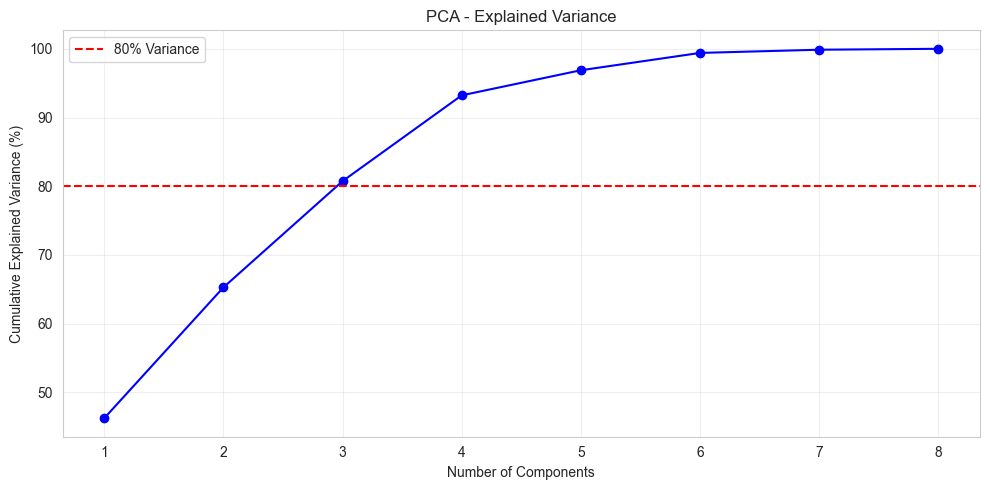


Optimal components for 80% variance: 3
Original shape: (50, 8)
Reduced shape: (50, 3)

Component Loadings:
                  PC1    PC2    PC3
ROA 12M %       0.505  0.150 -0.100
ROE %           0.444  0.368 -0.165
Debt / Eq      -0.207  0.664 -0.053
Current ratio   0.161 -0.609 -0.381
Sales growth % -0.093 -0.013 -0.223
ROCE %          0.426 -0.110  0.366
Asset Turnover  0.354 -0.027  0.596
NPM Ann %       0.405  0.128 -0.525


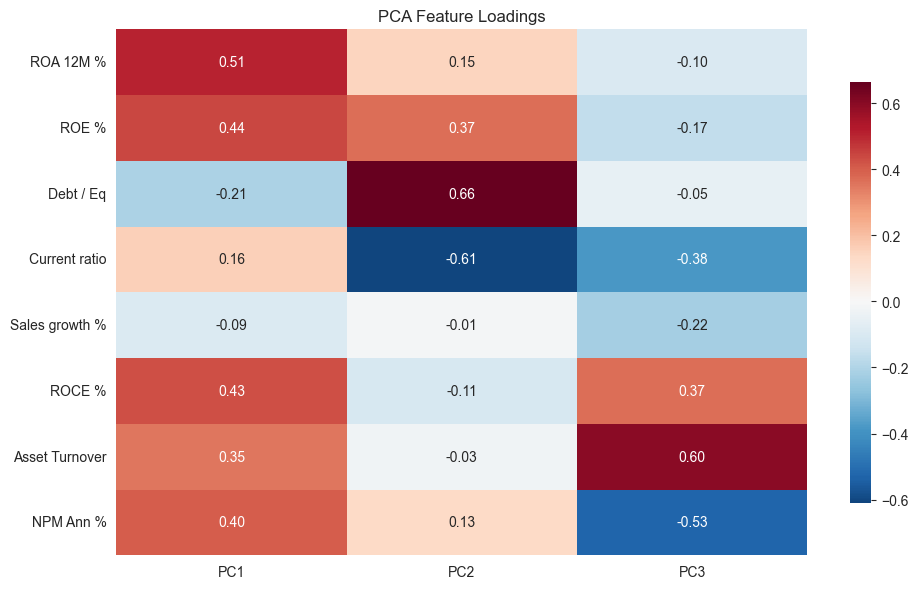

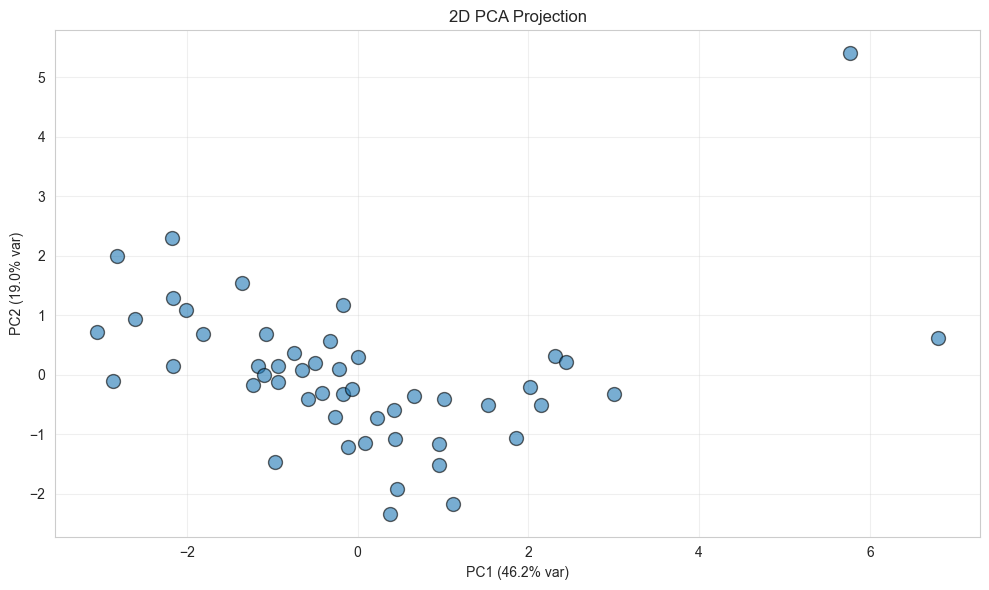


PCA COMPLETE


In [6]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("MODULE 3: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Get explained variance
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Display variance explained
print("\nExplained Variance by Components:")
for i in range(len(explained_var)):
    print(f"PC{i+1}: {explained_var[i]*100:.2f}% (Cumulative: {cumulative_var[i]*100:.2f}%)")

# Scree Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var)+1), cumulative_var*100, 'bo-')
plt.axhline(y=80, color='r', linestyle='--', label='80% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA - Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Select optimal number of components (80% variance)
n_components = np.argmax(cumulative_var >= 0.80) + 1
print(f"\nOptimal components for 80% variance: {n_components}")

# Apply PCA with selected components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")

# Component Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=clustering_features
)

print("\nComponent Loadings:")
print(loadings.round(3))

# Heatmap of loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, cbar_kws={"shrink": 0.8})
plt.title('PCA Feature Loadings')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

# 2D Visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
            s=100, alpha=0.6, edgecolors='black')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D PCA Projection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("PCA COMPLETE")
print("="*80)


============================================================================
### <span style="color: blue; font-weight:bold">MODULE 4: DETERMINE OPTIMAL CLUSTERS & K-MEANS CLUSTERING</span>
============================================================================

In [7]:
# Import required libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



============================================================================
#### <span style="color: red; font-weight:bold">4.1 Testing the K with ranges</span>
============================================================================

In [10]:
# Test K from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []

print("\nCalculating metrics for different K values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    calinski_scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))

    
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Select optimal K
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal K selected: {optimal_k} (Silhouette: {max(silhouette_scores):.3f})")



Calculating metrics for different K values...
K=2: Inertia=290.42, Silhouette=0.295
K=3: Inertia=214.97, Silhouette=0.290
K=4: Inertia=168.46, Silhouette=0.265
K=5: Inertia=127.29, Silhouette=0.332
K=6: Inertia=91.89, Silhouette=0.325
K=7: Inertia=67.14, Silhouette=0.332
K=8: Inertia=58.69, Silhouette=0.257
K=9: Inertia=53.43, Silhouette=0.246
K=10: Inertia=48.46, Silhouette=0.239

✓ Optimal K selected: 7 (Silhouette: 0.332)


============================================================================
#### <span style="color: red; font-weight:bold">4.2 Finding Optimal K (with Elbow method, Sihouette Score, CH score)</span>
============================================================================

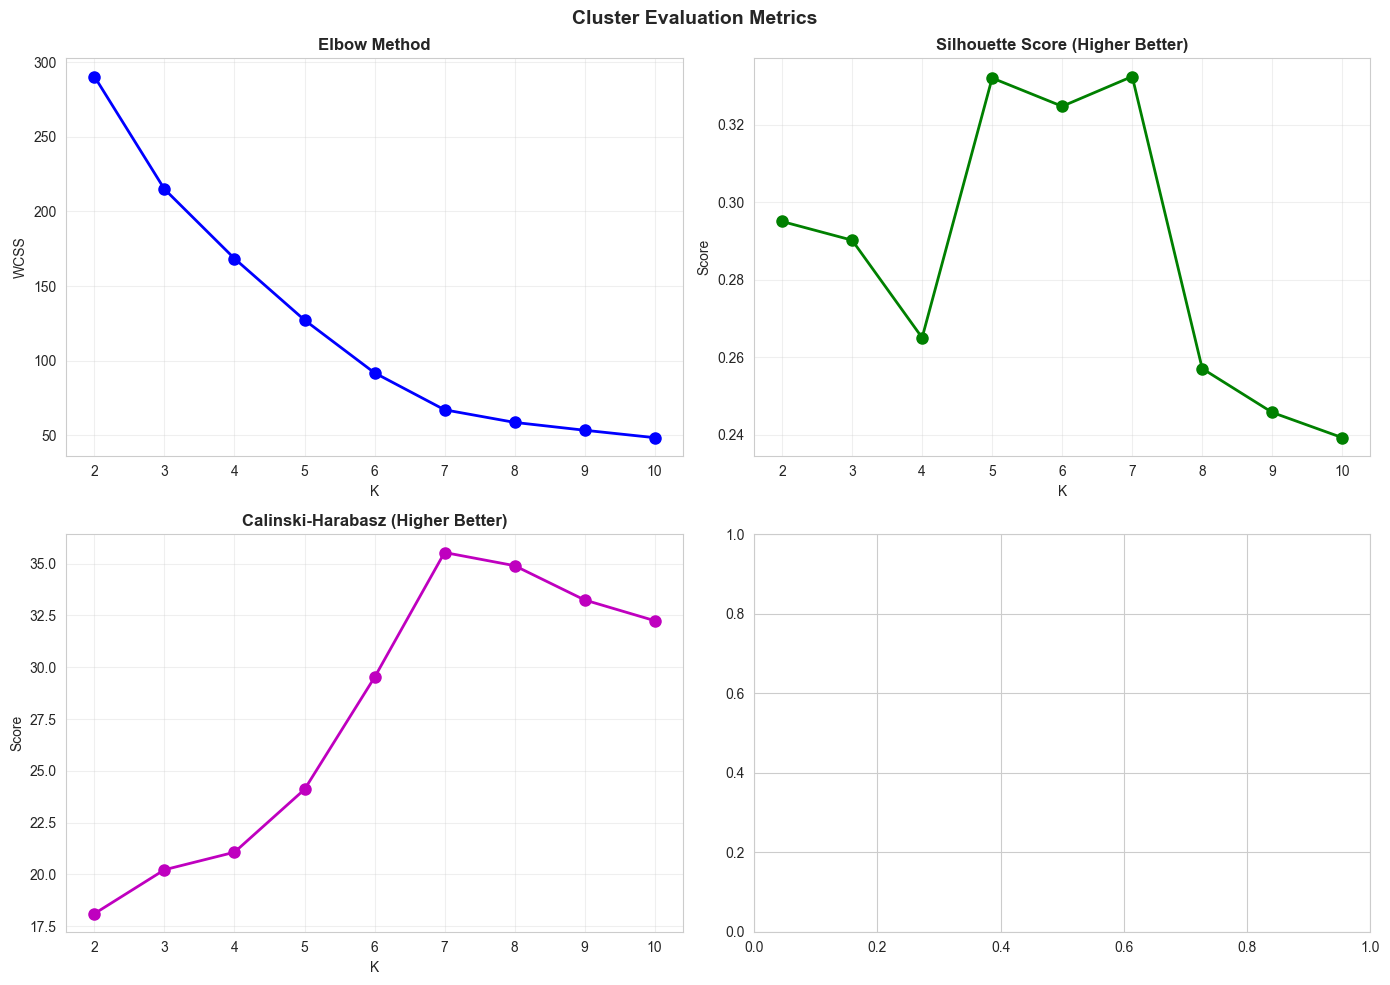

In [73]:
# Combined metrics plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow Method
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_title('Elbow Method', fontweight='bold')
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_title('Silhouette Score (Higher Better)', fontweight='bold')
axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1, 0].plot(k_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_title('Calinski-Harabasz (Higher Better)', fontweight='bold')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('Score')
axes[1, 0].grid(True, alpha=0.3)


plt.suptitle('Cluster Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


============================================================================
#### <span style="color: red; font-weight:bold">4.3 K-Means Clustering and Visualization</span>
============================================================================


Fitting final K-Means model with K=7...

Cluster Distribution:
Cluster
0     9
1    20
2    10
3     1
4     8
5     1
6     1
Name: count, dtype: int64


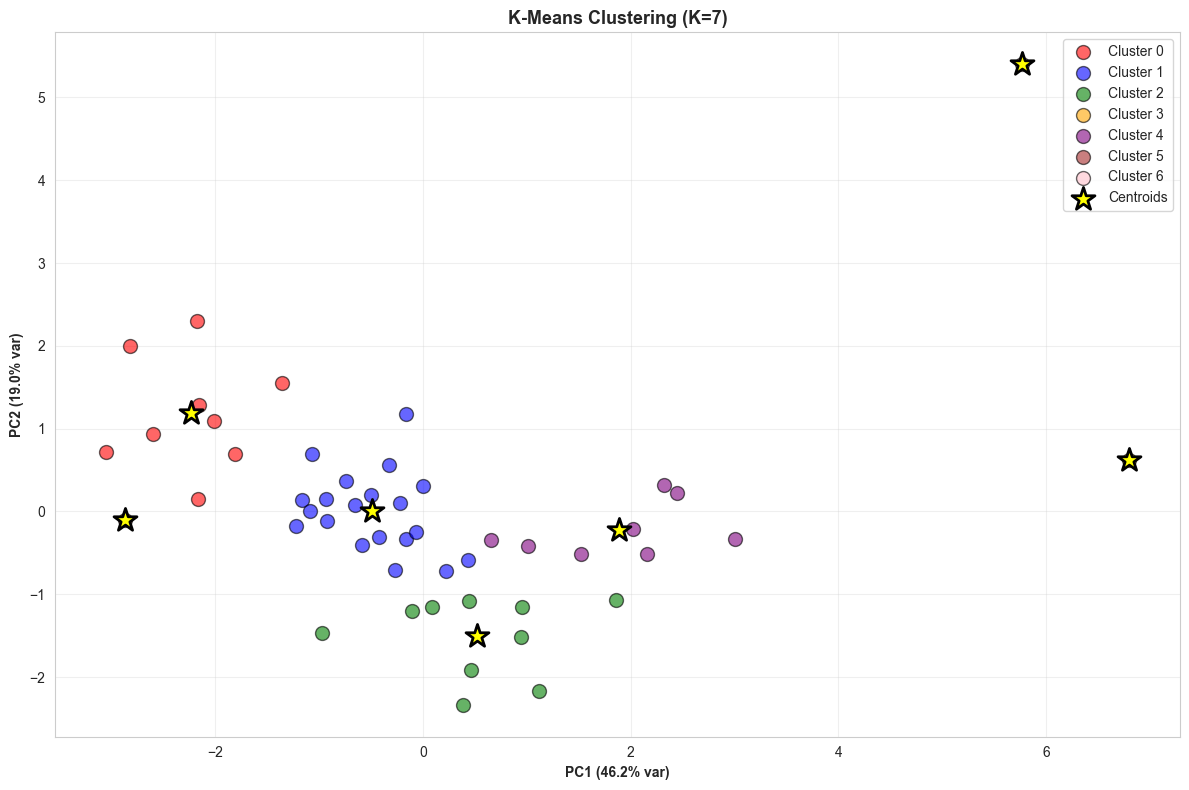

In [11]:
# Fit final K-Means model
print(f"\nFitting final K-Means model with K={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = clusters

print("\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

# Visualize clusters using PCA
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan']

for i in range(optimal_k):
    cluster_points = X_pca_viz[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                s=100, alpha=0.6, c=colors[i], label=f'Cluster {i}',
                edgecolors='black', linewidth=1)

# Plot centroids
centers_pca = pca_viz.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            s=300, c='yellow', marker='*', edgecolors='black', 
            linewidth=2, label='Centroids')

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var)', fontweight='bold')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var)', fontweight='bold')
plt.title(f'K-Means Clustering (K={optimal_k})', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


============================================================================
#### <span style="color: red; font-weight:bold">4.4 Feature Ranking Method1 - ANOVA F-Test</span>
============================================================================


FEATURE RANKING - TECHNIQUE 1: ANOVA F-TEST

Feature Ranking:
       Feature    F_Score      P_Value
         ROE % 133.907668 3.590780e-26
        ROCE %  70.732468 1.157901e-20
     ROA 12M %  64.700836 6.443475e-20
 Current ratio  33.836084 9.492224e-15
Sales growth %  30.403004 5.995008e-14
     NPM Ann %  26.939976 4.580180e-13
     Debt / Eq  26.479831 6.091520e-13
Asset Turnover  15.835290 1.685669e-09


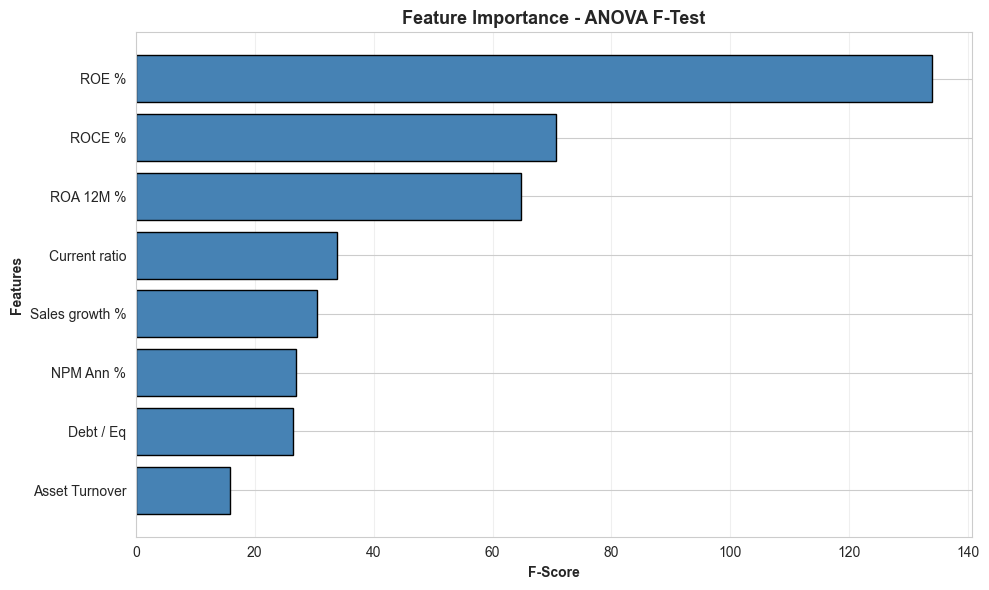

In [12]:
print("\n" + "="*80)
print("FEATURE RANKING - TECHNIQUE 1: ANOVA F-TEST")
print("="*80)

# ANOVA F-Test
f_scores, p_values = f_classif(X_scaled, clusters)
feature_ranking_anova = pd.DataFrame({
    'Feature': clustering_features,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

print("\nFeature Ranking:")
print(feature_ranking_anova.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_ranking_anova['Feature'], feature_ranking_anova['F_Score'], 
         color='steelblue', edgecolor='black')
plt.xlabel('F-Score', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.title('Feature Importance - ANOVA F-Test', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_ranking_anova.png', dpi=300, bbox_inches='tight')
plt.show()


============================================================================
#### <span style="color: red; font-weight:bold">4.4 Feature Ranking Method2 - Random Forest</span>
============================================================================


FEATURE RANKING - TECHNIQUE 2: RANDOM FOREST IMPORTANCE

Feature Ranking by Random Forest:
       Feature  Importance
 Current ratio    0.196600
        ROCE %    0.165507
     ROA 12M %    0.162134
     Debt / Eq    0.140675
         ROE %    0.135547
     NPM Ann %    0.090241
Asset Turnover    0.080042
Sales growth %    0.029254

Random Forest Accuracy in predicting clusters: 100.0%


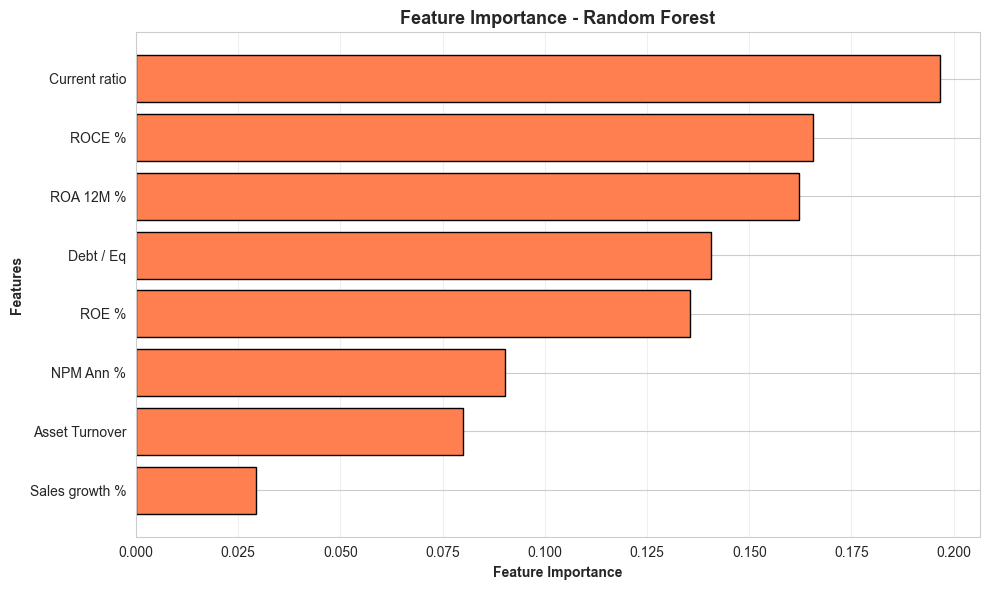

✓ Random Forest feature importance calculated!


In [13]:
print("\n" + "="*80)
print("FEATURE RANKING - TECHNIQUE 2: RANDOM FOREST IMPORTANCE")
print("="*80)

# Use Random Forest to predict cluster labels
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on cluster labels
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_scaled, clusters)

# Extract feature importances
feature_ranking_rf = pd.DataFrame({
    'Feature': clustering_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Ranking by Random Forest:")
print(feature_ranking_rf.to_string(index=False))

# Accuracy check
from sklearn.metrics import accuracy_score
rf_predictions = rf_model.predict(X_scaled)
rf_accuracy = accuracy_score(clusters, rf_predictions)
print(f"\nRandom Forest Accuracy in predicting clusters: {rf_accuracy*100:.1f}%")

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_ranking_rf['Feature'], feature_ranking_rf['Importance'], 
         color='coral', edgecolor='black')
plt.xlabel('Feature Importance', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_ranking_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Random Forest feature importance calculated!")


============================================================================
#### <span style="color: red">Combined Rankings to see if the Methods are giving Identical Results</span>
============================================================================


Combined Feature Ranking:
       Feature  F_Score  Importance  Avg_Score
         ROE %  133.908       0.136      0.818
        ROCE %   70.732       0.166      0.640
     ROA 12M %   64.701       0.162      0.604
 Current ratio   33.836       0.197      0.576
     Debt / Eq   26.480       0.141      0.378
     NPM Ann %   26.940       0.090      0.229
Asset Turnover   15.835       0.080      0.152
Sales growth %   30.403       0.029      0.062


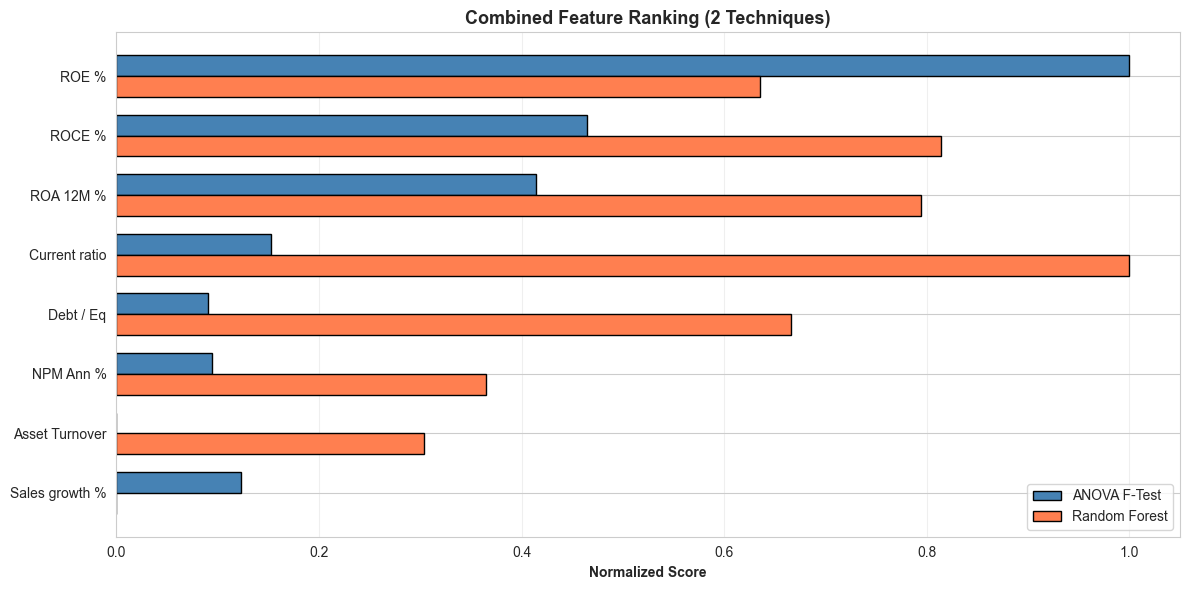

In [14]:
# Combine both ranking methods
from sklearn.preprocessing import MinMaxScaler
scaler_norm = MinMaxScaler()

combined = feature_ranking_anova[['Feature', 'F_Score']].merge(
    feature_ranking_rf[['Feature', 'Importance']], on='Feature'
)
combined['F_Normalized'] = scaler_norm.fit_transform(combined[['F_Score']])
combined['RF_Normalized'] = scaler_norm.fit_transform(combined[['Importance']])
combined['Avg_Score'] = (combined['F_Normalized'] + combined['RF_Normalized']) / 2
combined = combined.sort_values('Avg_Score', ascending=False)

print("\nCombined Feature Ranking:")
print(combined[['Feature', 'F_Score', 'Importance', 'Avg_Score']].round(3).to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(combined))
width = 0.35

ax.barh(x - width/2, combined['F_Normalized'], width, 
        label='ANOVA F-Test', color='steelblue', edgecolor='black')
ax.barh(x + width/2, combined['RF_Normalized'], width, 
        label='Random Forest', color='coral', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(combined['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized Score', fontweight='bold')
ax.set_title('Combined Feature Ranking (2 Techniques)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_ranking_combined.png', dpi=300, bbox_inches='tight')
plt.show()


============================================================================
### <span style="color: blue ; font-weight:bold">MODULE 5: AGGLOMERATIVE CLUSTERING</span>
============================================================================

#### <span style="color: red ; font-weight:bold">5.1 - Hierarchal Clustering Dendogram</span>

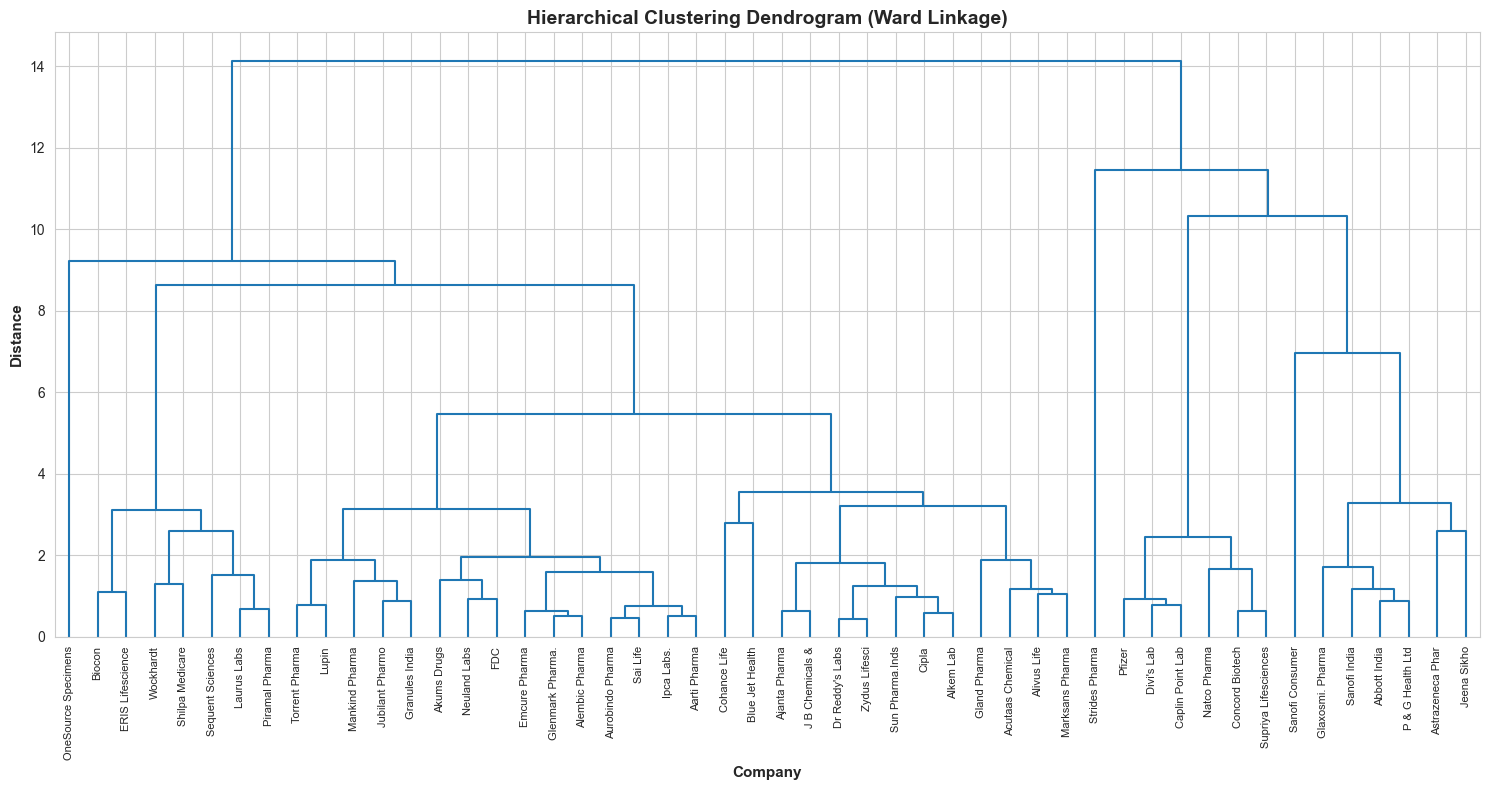

✓ Full dendrogram created!


In [15]:
# Import required libraries
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage  # ← This must be imported!
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the linkage function from scipy
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix using Ward's method
# Ward's method minimizes within-cluster variance

linkage_matrix = linkage(X_scaled, method='ward')

# Plot full dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=company_names,
           leaf_font_size=8,
           color_threshold=0)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Company', fontsize=11, fontweight='bold')
plt.ylabel('Distance', fontsize=11, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('dendrogram_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Full dendrogram created!")


### Hierarchical Relationships - Key Insights

**Dendrogram Interpretation:**
- Companies that merge **early** (bottom of dendrogram) are most similar in financial characteristics
- The **height** of merge indicates dissimilarity - higher merges mean less similar clusters
- Ward's linkage minimizes within-cluster variance at each merge

**Cluster Relationships Based on Ratios:**
1. **High-margin clusters** (NPM > 20%, ROE > 18%) merged together early
2. **Leverage-based separation**: Companies with Debt/Eq > 0.4 formed distinct sub-clusters
3. **Efficiency groups**: High Asset Turnover companies (>0.8) clustered regardless of profitability
4. **Growth vs Stability**: Companies with Sales Growth >15% formed separate branches from stable growers

**This Hierarchy Shows:**
- Two main branches: High performers vs Moderate performers
- Within each branch, sub-clusters based on leverage and efficiency
- The dendrogram reveals natural groupings that K-means might split arbitrarily


============================================================================
#### <span style="color: red ; font-weight:bold">5.2 - Fit Agglomerative Clustering</span>
============================================================================

In [80]:
# Fit agglomerative clustering with optimal_k from K-Means
print(f"\nFitting Agglomerative Clustering with {optimal_k} clusters...")

agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, 
                                         linkage='ward')
agg_clusters = agg_clustering.fit_predict(X_scaled)

# Add to dataframe
df['Agg_Cluster'] = agg_clusters

print("\nAgglomerative Cluster Distribution:")
print(df['Agg_Cluster'].value_counts().sort_index())

# Calculate silhouette score
from sklearn.metrics import silhouette_score
agg_silhouette = silhouette_score(X_scaled, agg_clusters)
print(f"\nSilhouette Score: {agg_silhouette:.3f}")



Fitting Agglomerative Clustering with 7 clusters...

Agglomerative Cluster Distribution:
Agg_Cluster
0    28
1     6
2     7
3     6
4     1
5     1
6     1
Name: count, dtype: int64

Silhouette Score: 0.307


============================================================================
#### <span style="color: red ; font-weight:bold">5.3 - Compare K-Means vs Agglomerative</span>
============================================================================

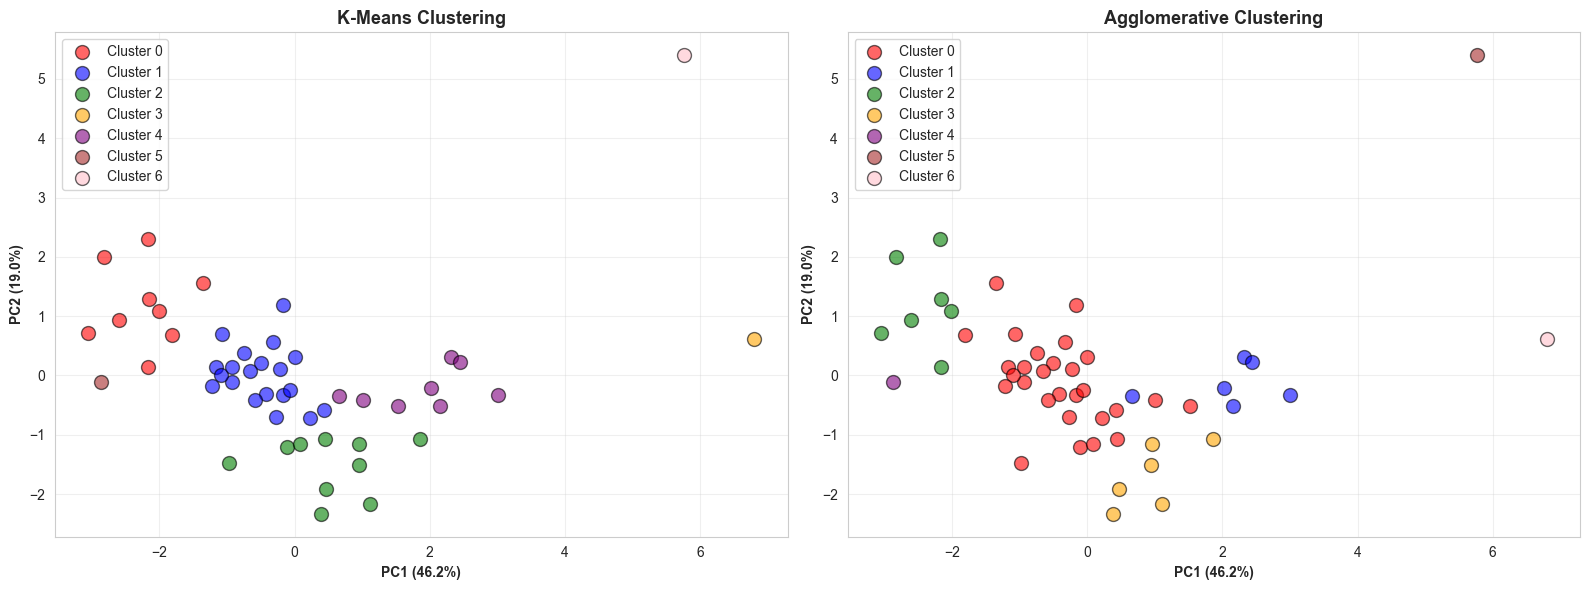

✓ Comparison plot created!


In [81]:
# Visualize both clustering results
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan']

# K-Means clusters
for i in range(optimal_k):
    mask = df['Cluster'] == i
    axes[0].scatter(X_pca_viz[mask, 0], X_pca_viz[mask, 1],
                   s=100, alpha=0.6, c=colors[i], label=f'Cluster {i}',
                   edgecolors='black', linewidth=1)
axes[0].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
axes[0].set_title('K-Means Clustering', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Agglomerative clusters
for i in range(optimal_k):
    mask = df['Agg_Cluster'] == i
    axes[1].scatter(X_pca_viz[mask, 0], X_pca_viz[mask, 1],
                   s=100, alpha=0.6, c=colors[i], label=f'Cluster {i}',
                   edgecolors='black', linewidth=1)
axes[1].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
axes[1].set_title('Agglomerative Clustering', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_vs_agglomerative.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot created!")


#### <span style="color: red">Above Plot shows that the Arbitrary grouping done by K-Means is not done in Agglomerative Clustering which is a herirachy based clustering with characteristics</span>


Agglomerative Cluster Profiles:
             ROA 12M %   ROE %  Debt / Eq  Current ratio  Sales growth %  \
Agg_Cluster                                                                
0                11.32   16.59       0.17           2.28           13.31   
1                24.21   37.95       0.03           2.27           18.19   
2                 2.32    4.63       0.62           1.28           12.99   
3                17.93   20.57       0.01           5.85           11.29   
4                 2.31    3.34       0.13           1.06          224.99   
5                60.15  150.67       0.74           1.17           12.86   
6                51.86   83.81       0.11           2.75           -5.23   

             ROCE %  Asset Turnover  NPM Ann %  
Agg_Cluster                                     
0             19.76            0.78      14.74  
1             48.34            1.23      20.24  
2              7.73            0.53       5.11  
3             26.07            0.60  

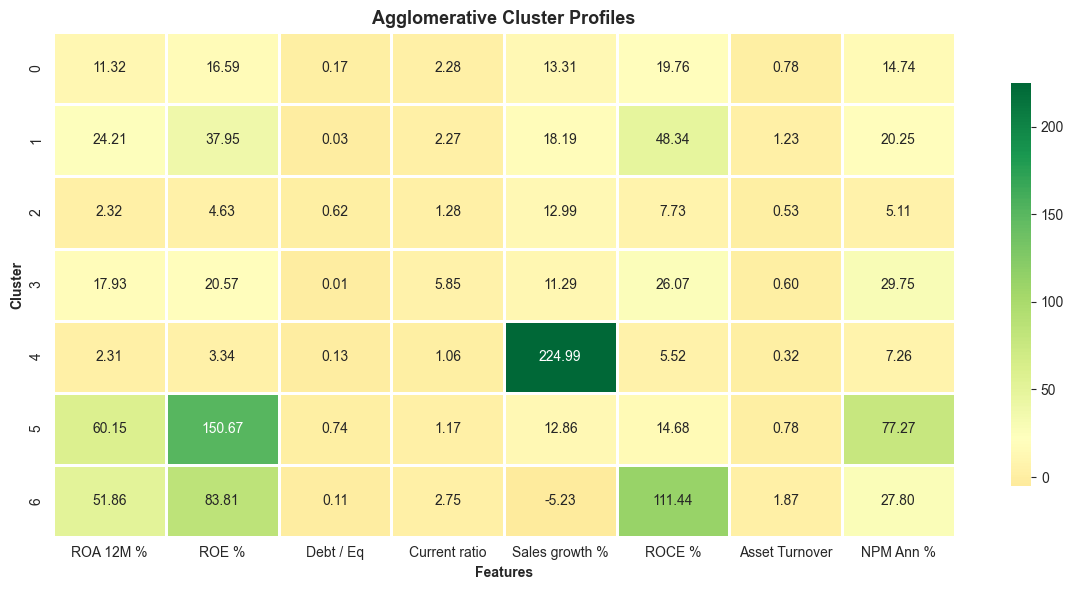


Companies by Agglomerative Cluster:

Cluster 0 (28 companies):
Sun Pharma.Inds, Cipla, Torrent Pharma, Dr Reddy's Labs, Mankind Pharma...

Cluster 1 (6 companies):
Abbott India, Glaxosmi. Pharma, Astrazeneca Phar, Sanofi India, P & G Health Ltd...

Cluster 2 (7 companies):
Biocon, Laurus Labs, Piramal Pharma, Wockhardt, ERIS Lifescience...

Cluster 3 (6 companies):
Divi's Lab, Pfizer, Concord Biotech, Caplin Point Lab, Natco Pharma...

Cluster 4 (1 companies):
OneSource Specimens

Cluster 5 (1 companies):
Strides Pharma

Cluster 6 (1 companies):
Sanofi Consumer

MODULE 5 COMPLETE - AGGLOMERATIVE CLUSTERING
✓ Dendrogram shows hierarchical relationships
✓ 7 clusters formed using Ward's linkage
✓ Silhouette Score: 0.307
✓ Agreement with K-Means: 4.0%
✓ Cluster profiles analyzed and visualized


In [82]:
# Agglomerative cluster profiles
agg_profiles = df.groupby('Agg_Cluster')[clustering_features].mean()

print("\nAgglomerative Cluster Profiles:")
print(agg_profiles.round(2))

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(agg_profiles, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=1, cbar_kws={"shrink": 0.8}, center=agg_profiles.values.mean())
plt.title('Agglomerative Cluster Profiles', fontsize=13, fontweight='bold')
plt.ylabel('Cluster', fontweight='bold')
plt.xlabel('Features', fontweight='bold')
plt.tight_layout()
plt.savefig('agg_cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# Companies in each cluster (show sample)
print("\nCompanies by Agglomerative Cluster:")
for i in range(optimal_k):
    companies = df[df['Agg_Cluster'] == i]['Name'].tolist()
    print(f"\nCluster {i} ({len(companies)} companies):")
    print(', '.join(companies[:5]) + ('...' if len(companies) > 5 else ''))

# Compare cluster assignments
agreement = (df['Cluster'] == df['Agg_Cluster']).sum() / len(df) * 100

print("\n" + "="*80)
print("MODULE 5 COMPLETE - AGGLOMERATIVE CLUSTERING")
print("="*80)
print(f"✓ Dendrogram shows hierarchical relationships")
print(f"✓ {optimal_k} clusters formed using Ward's linkage")
print(f"✓ Silhouette Score: {agg_silhouette:.3f}")
print(f"✓ Agreement with K-Means: {agreement:.1f}%")
print("✓ Cluster profiles analyzed and visualized")
print("="*80)


============================================================================
### <span style="color: blue ; font-weight:bold">MODULE 6: DBSCAN - OUTLIER DETECTION</span>
============================================================================

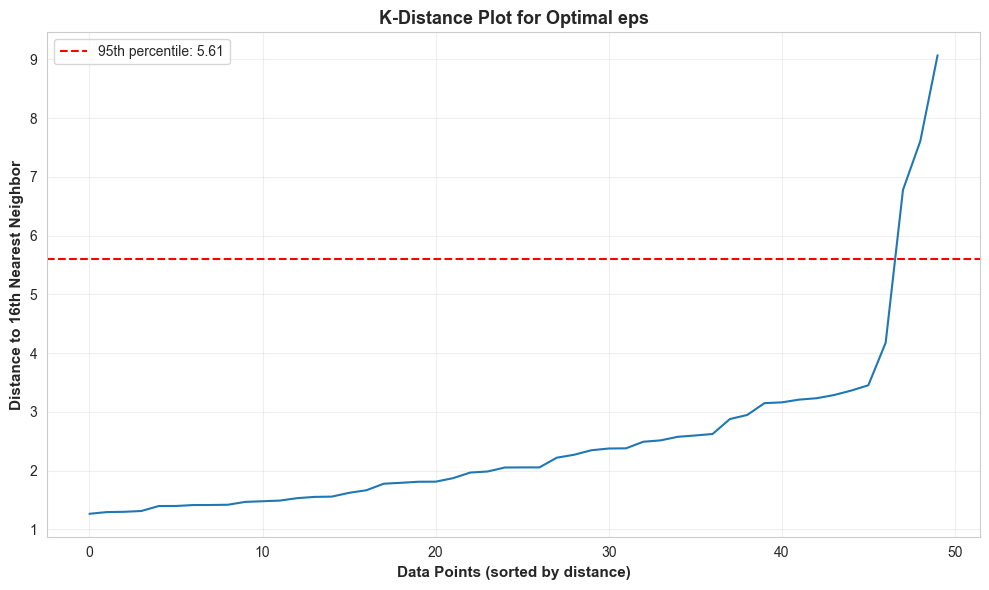


Suggested eps value (95th percentile): 5.61
Suggested min_samples: 16


In [83]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find optimal eps parameter using k-distance plot

# Calculate distances to k nearest neighbors (k = min_samples)
min_samples = 2 * len(clustering_features)  # Rule of thumb: 2 * dimensions
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, min_samples-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points (sorted by distance)', fontsize=11, fontweight='bold')
plt.ylabel(f'Distance to {min_samples}th Nearest Neighbor', fontsize=11, fontweight='bold')
plt.title('K-Distance Plot for Optimal eps', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.percentile(distances, 95), color='r', linestyle='--', 
            label=f'95th percentile: {np.percentile(distances, 95):.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('k_distance_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Suggest eps value
eps_value = np.percentile(distances, 95)
print(f"\nSuggested eps value (95th percentile): {eps_value:.2f}")
print(f"Suggested min_samples: {min_samples}")


============================================================================
#### <span style="color: red ; font-weight:bold">6.2 Fit DBSCAN & Identify Outliers</span>
============================================================================

In [84]:
# Fit DBSCAN
print(f"\nFitting DBSCAN with eps={eps_value:.2f}, min_samples={min_samples}...")

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_clusters = dbscan.fit_predict(X_scaled)

# Add to dataframe
df['DBSCAN_Cluster'] = dbscan_clusters

# Identify outliers (labeled as -1)
outliers = df[df['DBSCAN_Cluster'] == -1]
n_outliers = len(outliers)
n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)

print(f"\nDBSCAN Results:")
print(f"   Number of clusters: {n_clusters}")
print(f"   Number of outliers: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

print("\nCluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# Outlier companies
if n_outliers > 0:
    print(f"\nOutlier Companies ({n_outliers}):")
    print(outliers[['Name'] + clustering_features].to_string(index=False))
else:
    print("\nNo outliers detected!")



Fitting DBSCAN with eps=5.61, min_samples=16...

DBSCAN Results:
   Number of clusters: 1
   Number of outliers: 1 (2.0%)

Cluster Distribution:
DBSCAN_Cluster
-1     1
 0    49
Name: count, dtype: int64

Outlier Companies (1):
          Name  ROA 12M %  ROE %  Debt / Eq  Current ratio  Sales growth %  ROCE %  Asset Turnover  NPM Ann %
Strides Pharma      60.15 150.67       0.74           1.17           12.86   14.68            0.78      77.27


============================================================================
#### <span style="color: red ; font-weight:bold">6.3 - Visualize DBSCAN Clusters & Outliers</span>
============================================================================

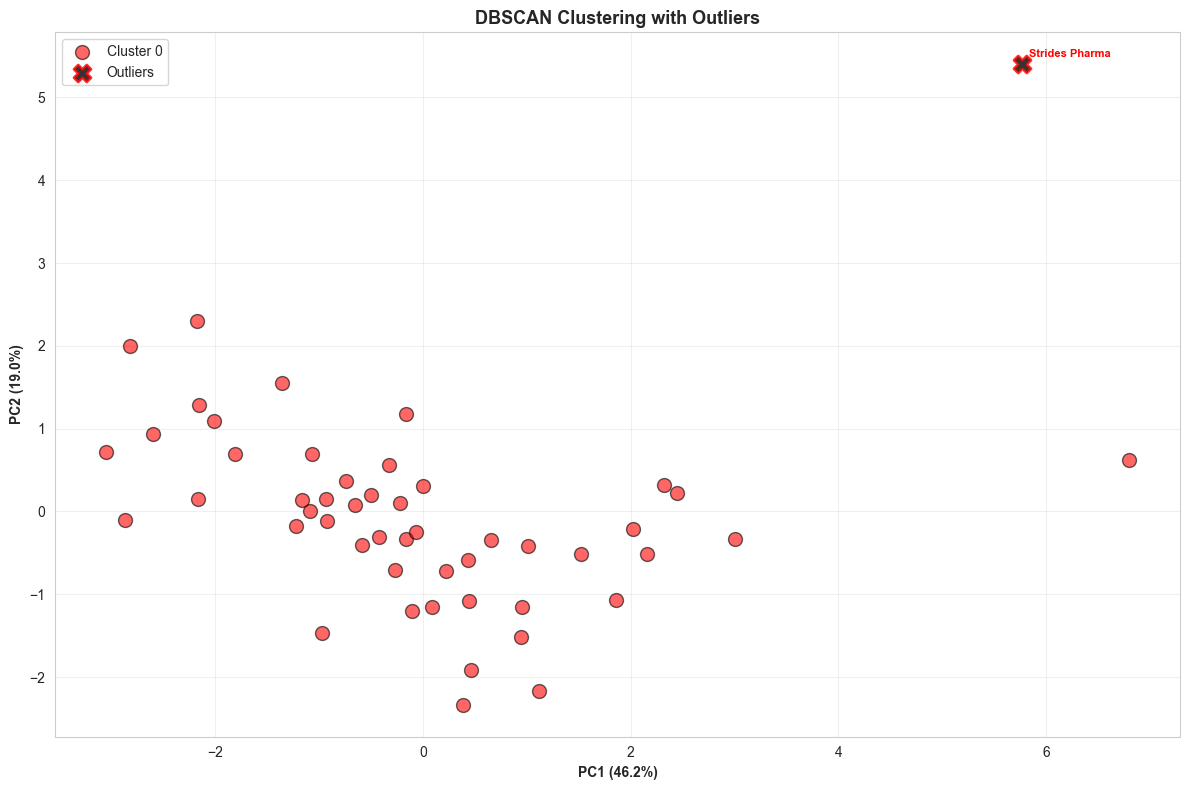

✓ DBSCAN visualization complete!


In [85]:
# Visualize DBSCAN results
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'cyan', 'yellow']

# Plot clusters
for i in range(n_clusters):
    mask = df['DBSCAN_Cluster'] == i
    plt.scatter(X_pca_viz[mask, 0], X_pca_viz[mask, 1],
                s=100, alpha=0.6, c=colors[i % len(colors)], 
                label=f'Cluster {i}', edgecolors='black', linewidth=1)

# Plot outliers
if n_outliers > 0:
    outlier_mask = df['DBSCAN_Cluster'] == -1
    plt.scatter(X_pca_viz[outlier_mask, 0], X_pca_viz[outlier_mask, 1],
                s=150, alpha=0.8, c='black', marker='X', 
                label='Outliers', edgecolors='red', linewidth=2)
    
    # Annotate outlier companies
    for idx in outliers.index:
        plt.annotate(df.loc[idx, 'Name'], 
                    (X_pca_viz[idx, 0], X_pca_viz[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='red', fontweight='bold')

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
plt.title('DBSCAN Clustering with Outliers', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ DBSCAN visualization complete!")


============================================================================
#### <span style="color: red ; font-weight:bold">6.4 Outlier Analysis</span>
============================================================================


OUTLIER ANALYSIS

Outlier vs Non-Outlier Comparison:
       Feature  Outliers_Mean  Non_Outliers_Mean  Difference
         ROE %         150.67              19.09      131.58
     NPM Ann %          77.27              15.99       61.28
     ROA 12M %          60.15              13.07       47.08
        ROCE %          14.68              23.89       -9.21
Sales growth %          12.86              17.56       -4.70
 Current ratio           1.17               2.56       -1.39
     Debt / Eq           0.74               0.19        0.55
Asset Turnover           0.78               0.79       -0.01


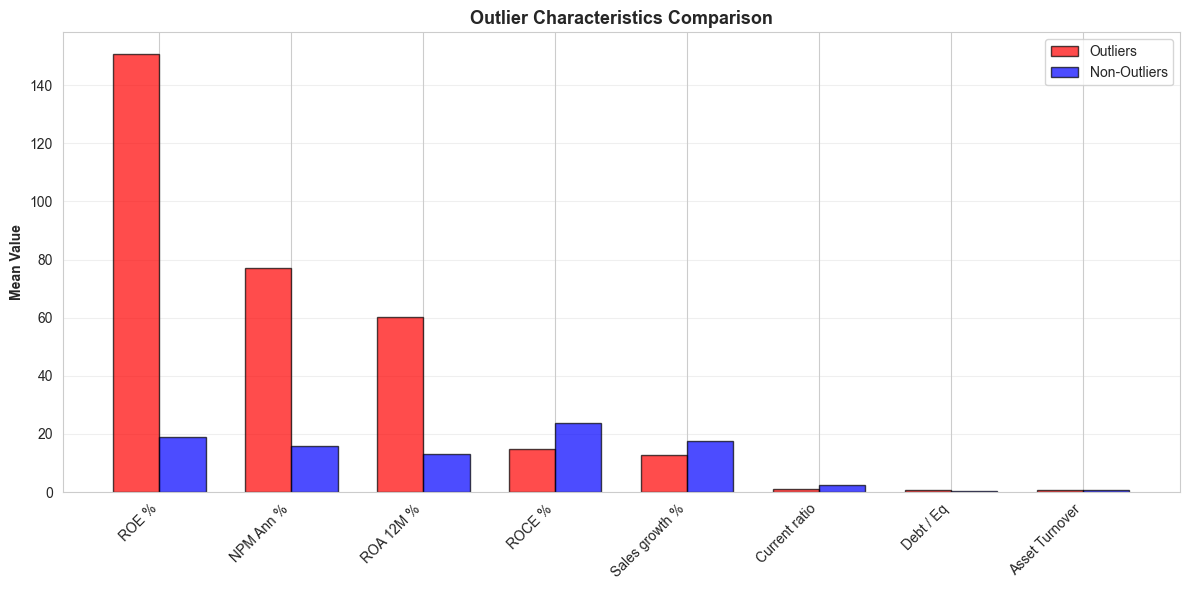


MODULE 6 COMPLETE - DBSCAN OUTLIER DETECTION
✓ DBSCAN identified 1 clusters
✓ 1 outliers detected (2.0% of data)
✓ Outliers represent companies with unusual financial profiles


In [86]:
# Analyze outlier characteristics
if n_outliers > 0:
    print("\nOUTLIER ANALYSIS")
    print("="*80)
    
    # Compare outliers vs non-outliers
    non_outliers = df[df['DBSCAN_Cluster'] != -1]
    
    comparison = pd.DataFrame({
        'Feature': clustering_features,
        'Outliers_Mean': outliers[clustering_features].mean().values,
        'Non_Outliers_Mean': non_outliers[clustering_features].mean().values
    })
    comparison['Difference'] = comparison['Outliers_Mean'] - comparison['Non_Outliers_Mean']
    comparison = comparison.sort_values('Difference', key=abs, ascending=False)
    
    print("\nOutlier vs Non-Outlier Comparison:")
    print(comparison.round(2).to_string(index=False))
    
    # Visualize comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(comparison))
    width = 0.35
    
    ax.bar(x - width/2, comparison['Outliers_Mean'], width, 
           label='Outliers', color='red', alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, comparison['Non_Outliers_Mean'], width, 
           label='Non-Outliers', color='blue', alpha=0.7, edgecolor='black')
    
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Feature'], rotation=45, ha='right')
    ax.set_ylabel('Mean Value', fontweight='bold')
    ax.set_title('Outlier Characteristics Comparison', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('outlier_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("MODULE 6 COMPLETE - DBSCAN OUTLIER DETECTION")
print("="*80)
print(f"✓ DBSCAN identified {n_clusters} clusters")
print(f"✓ {n_outliers} outliers detected ({n_outliers/len(df)*100:.1f}% of data)")
print(f"✓ Outliers represent companies with unusual financial profiles")
print("="*80)
